# EXP-12 -PROJECT: Face Detection with Haar Cascades
# NAME : DODLA SUSMITHA
# REG NO : 212224110016

In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

In [2]:
w_glass = cv2.imread('image_02.png', cv2.IMREAD_GRAYSCALE)
wo_glass = cv2.imread('image_01.png', cv2.IMREAD_GRAYSCALE)
group = cv2.imread('image_03.png', cv2.IMREAD_GRAYSCALE)

In [3]:
w_glass1 = cv2.resize(w_glass, (1000, 1000))
wo_glass1 = cv2.resize(wo_glass, (1000, 1000)) 
group1 = cv2.resize(group, (1000, 1000))

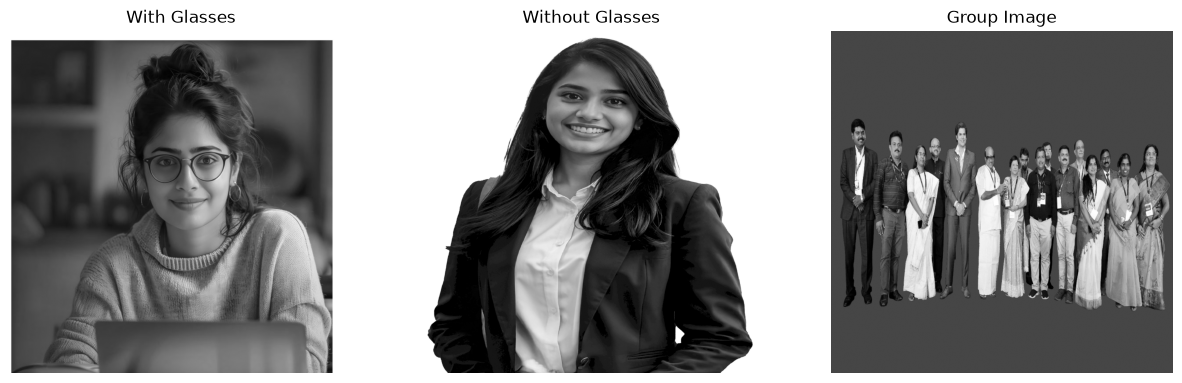

In [4]:
plt.figure(figsize=(15,10))
plt.subplot(1,3,1);plt.imshow(w_glass1,cmap='gray');plt.title('With Glasses');plt.axis('off')
plt.subplot(1,3,2);plt.imshow(wo_glass1,cmap='gray');plt.title('Without Glasses');plt.axis('off')
plt.subplot(1,3,3);plt.imshow(group1,cmap='gray');plt.title('Group Image');plt.axis('off')
plt.show()

In [5]:
face_cascade = cv2.CascadeClassifier('haarcascade_frontalface_default.xml')
def detect_and_display(image):
    faces = face_cascade.detectMultiScale(image, scaleFactor=1.1, minNeighbors=5)
    for (x, y, w, h) in faces:
        cv2.rectangle(image, (x, y), (x + w, y + h), (255, 0, 0), 10)
    plt.imshow(image, cmap='gray')
    plt.axis('off')
    plt.show()

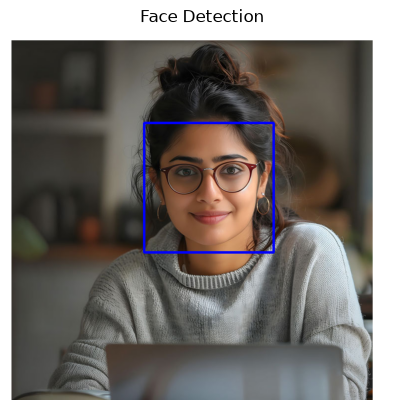

In [12]:
import cv2
import urllib.request
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/opencv/opencv/master/data/haarcascades/haarcascade_frontalface_default.xml"
urllib.request.urlretrieve(url, "face.xml")

face_cascade = cv2.CascadeClassifier("face.xml")

image = cv2.imread("image_02.png")
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

faces = face_cascade.detectMultiScale(gray, 1.1, 5)

for (x, y, w, h) in faces:
    cv2.rectangle(image, (x, y), (x+w, y+h), (255, 0, 0), 3)

plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title("Face Detection")
plt.axis("off")
plt.show()

In [13]:
from IPython.display import clear_output, display
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
eye_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_eye.xml')

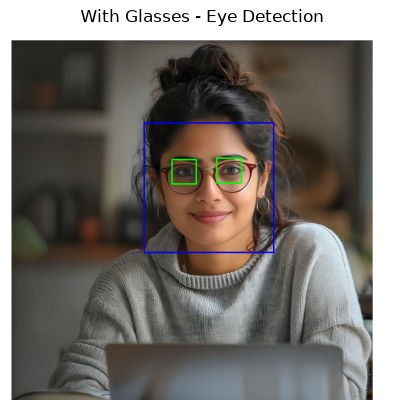

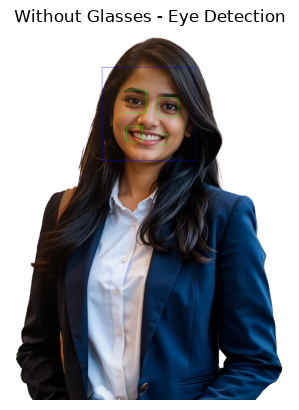

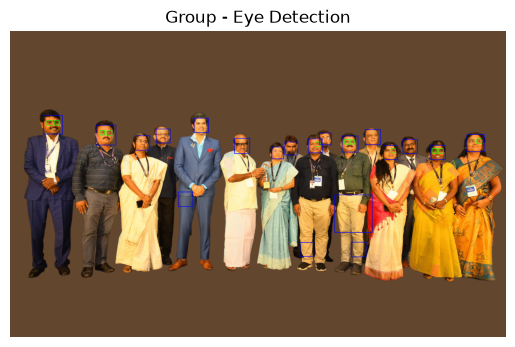

In [15]:
import cv2
import urllib.request
import matplotlib.pyplot as plt

# Download Haar cascade files
urllib.request.urlretrieve(
    "https://raw.githubusercontent.com/opencv/opencv/master/data/haarcascades/haarcascade_frontalface_default.xml",
    "face.xml")

urllib.request.urlretrieve(
    "https://raw.githubusercontent.com/opencv/opencv/master/data/haarcascades/haarcascade_eye.xml",
    "eye.xml")

face_cascade = cv2.CascadeClassifier("face.xml")
eye_cascade = cv2.CascadeClassifier("eye.xml")

# Load images
w_glass = cv2.imread("image_02.png")
wo_glass = cv2.imread("image_01.png")
group = cv2.imread("image_03.png")

def detect_eyes(image):
    result = image.copy()
    gray = cv2.cvtColor(result, cv2.COLOR_BGR2GRAY)

    faces = face_cascade.detectMultiScale(gray, 1.1, 5)

    for (x, y, w, h) in faces:
        cv2.rectangle(result, (x, y), (x+w, y+h), (255, 0, 0), 2)

        roi = gray[y:y+h, x:x+w]
        eyes = eye_cascade.detectMultiScale(roi, 1.1, 5)

        for (ex, ey, ew, eh) in eyes:
            cv2.rectangle(result, (x+ex, y+ey),
                          (x+ex+ew, y+ey+eh), (0, 255, 0), 2)

    return result

for image, title in [
    (w_glass, "With Glasses - Eye Detection"),
    (wo_glass, "Without Glasses - Eye Detection"),
    (group, "Group - Eye Detection")
]:
    if image is not None:
        result = detect_eyes(image)
        plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
        plt.title(title)
        plt.axis("off")
        plt.show()

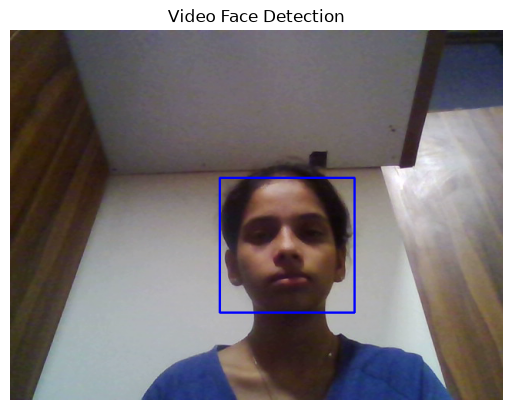

In [18]:
import cv2
import urllib.request
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/opencv/opencv/master/data/haarcascades/haarcascade_frontalface_default.xml"
urllib.request.urlretrieve(url, "face.xml")

face_cascade = cv2.CascadeClassifier("face.xml")
cap = cv2.VideoCapture(0)

ret, frame = cap.read()

if ret:
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, 1.1, 5)

    for (x, y, w, h) in faces:
        cv2.rectangle(frame, (x, y), (x+w, y+h), (255, 0, 0), 2)

    plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    plt.title("Video Face Detection")
    plt.axis("off")
    plt.show()
else:
    print("No frame captured from camera.")

cap.release()

In [19]:
def new_detect(gray, frame):
    faces = face_cascade.detectMultiScale(gray, 1.3, 5)
    for (x, y, w, h) in faces:
        cv2.rectangle(frame, (x, y), (x + w, y + h), (255, 0, 0), 2)
        roi_gray = gray[y:y + h, x:x + w]
        roi_color = frame[y:y + h, x:x + w]
        eyes = eye_cascade.detectMultiScale(roi_gray)
        for (ex, ey, ew, eh) in eyes:
            cv2.rectangle(roi_color, (ex, ey), (ex + ew, ey + eh), (0, 255, 0), 2)
    return frame

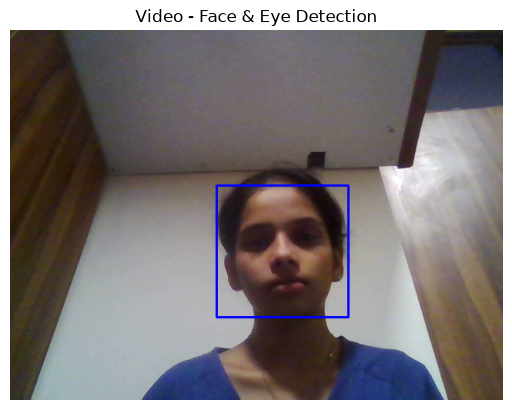

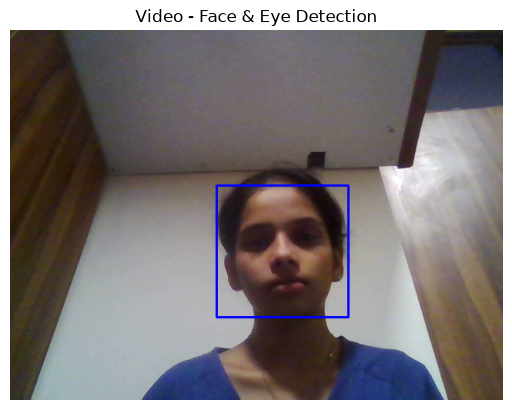

In [20]:
video_capture = cv2.VideoCapture(0)
captured_frame = None   

while True:
    ret, frame = video_capture.read()
    if not ret:
        print("No frame captured from camera.")
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    canvas = new_detect(gray, frame)
    clear_output(wait=True)
    plt.imshow(cv2.cvtColor(canvas, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.title("Video - Face & Eye Detection")
    display(plt.gcf())
    captured_frame = canvas.copy()  
    break

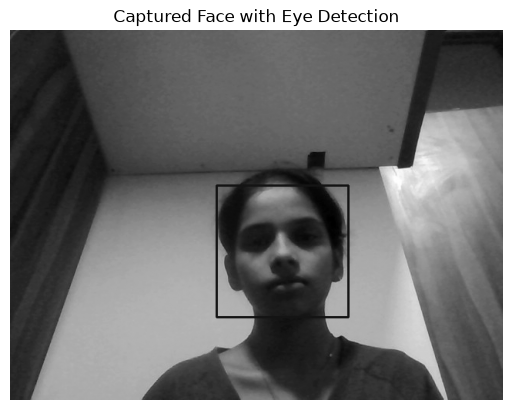

In [21]:
video_capture.release()
if captured_frame is not None and captured_frame.size > 0:
    cv2.imwrite('captured_face_eye.png', captured_frame)
    captured_image = cv2.imread('captured_face_eye.png', cv2.IMREAD_GRAYSCALE)
    plt.imshow(captured_image, cmap='gray')
    plt.title('Captured Face with Eye Detection')
    plt.axis('off')
    plt.show()
else:
    print("No valid frame to save.")

In [22]:
image = cv2.imread('image_04.png') 
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) 

plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis('off')

gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) 

blurred_image = cv2.GaussianBlur(gray_image, (5, 5), 0) 

edges = cv2.Canny(blurred_image, 50, 150)  

plt.imshow(edges, cmap='gray')
plt.title("Canny Edge Detection")
plt.axis('off')

error: OpenCV(5.0.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\color.cpp:199: error: (-215:Assertion failed) !_src.empty() in function 'cv::cvtColor'
